In [1]:
# Import Data manipulation libraries and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import filter warnings
import warnings
warnings.filterwarnings("ignore")

# Import OrderedDict
from collections import OrderedDict

# Import Logging
import logging
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    filename='Phissing.log',
                    filemode='w',
                    force=True)

# Import Sklearn libraries
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost
from xgboost import XGBClassifier

# AutoML
from flaml import AutoML

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Data Ingestion

df = pd.read_csv(r'C:\Phissing_Prediction_Model\data\raw\Phissing_Dataset.csv')

# Remove URL column (identifier, useless for model)
if 'url' in df.columns:
    df.drop(columns=['url'], inplace=True)

print("Dataset Shape:", df.shape)

# Encoding the Target columns

target = 'status'

le = LabelEncoder()
df[target] = le.fit_transform(df[target])

X = df.drop(columns=[target])
y = df[target]

# Applying Train and Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Removing columns who have only 1 unique values in which have nothing to do with ML Models

constant_cols = [col for col in X_train.columns if X_train[col].nunique() == 1]

print("Constant columns removed:", constant_cols)

X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

# Removal of IQR = 0 columns

iqr_zero_cols = []

for col in X_train.select_dtypes(include=['int64', 'float64']).columns:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0:
        iqr_zero_cols.append(col)

print("IQR = 0 columns removed:", iqr_zero_cols)

X_train = X_train.drop(columns=iqr_zero_cols)
X_test = X_test.drop(columns=iqr_zero_cols)

# Pipelines creation

numerical_cols = X_train.select_dtypes(exclude='object').columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Column transformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

# Smote and PCA application

final_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA(n_components=0.95, random_state=42))
])

# Training Preprocessing

print("Processing training data...")

# Preprocess
X_train_preprocessed = final_pipeline.named_steps['preprocessor'].fit_transform(X_train)

# Apply SMOTE
X_train_smoted, y_train_resampled = final_pipeline.named_steps['smote'].fit_resample(
    X_train_preprocessed, y_train
)

print(f"Original training size: {len(X_train)} → After SMOTE: {len(X_train_smoted)}")

# Apply PCA
pca = final_pipeline.named_steps['pca']
X_train_resampled = pca.fit_transform(X_train_smoted)

print(f"After PCA components: {X_train_resampled.shape[1]}")

# Test Data Preprocessing

print("\nProcessing test data...")

X_test_preprocessed = final_pipeline.named_steps['preprocessor'].transform(X_test)

X_test_transformed = pca.transform(X_test_preprocessed)

# Applying AutoML

automl = AutoML()

settings = {
    "time_budget": 300,
    "metric": "accuracy",
    "task": "classification",
    "estimator_list": ["rf", "extra_tree", "xgboost", "lrl2"],
    "log_file_name": "flaml.log",
    "seed": 42
}

# Train on processed features
automl.fit(X_train=X_train_resampled, y_train=y_train_resampled, **settings)

print("FLAML Training Completed")

best_model = getattr(automl, "best_estimator", None)

if best_model is not None:
    print("Best Model:", best_model)
else:
    print("FLAML did not find a model.")

# Prediction

y_pred = automl.predict(X_test_transformed)

# Model Evaluation

print("\nModel Performance")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Dataset Shape: (11430, 88)
Constant columns removed: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
IQR = 0 columns removed: ['ip', 'nb_at', 'nb_qm', 'nb_and', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_com', 'nb_dslash', 'http_in_path', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_external_redirection', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'login_form', 'iframe', 'popup_window', 'onmouseover', 'right_clic', 'empty_title', 'domain_in_title', 'whois_registered_domain', 'dns_record']
Processing training data...
Original training size: 8001 → After SMOTE: 8002
After PCA components: 15

Processing test data...
[flaml.automl.logger: 03-08 16:43:18

In [5]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation Metrics")
print("-------------------------")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")

Model Evaluation Metrics
-------------------------
Accuracy   : 0.9466
Precision  : 0.9484
Recall     : 0.9446
F1 Score   : 0.9465
ROC-AUC    : 0.9834


ROC-AUC Score: 0.9833866868967958


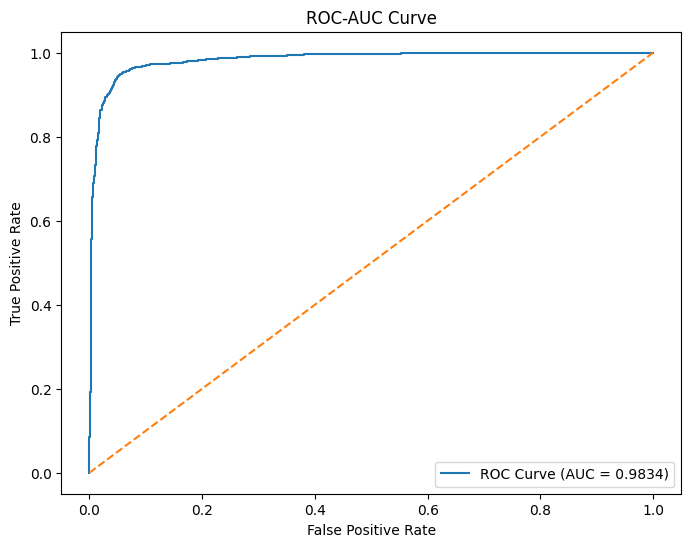

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score

# Normal predictions
y_pred = automl.predict(X_test_transformed)

# Probability predictions (needed for ROC)
y_prob = automl.predict_proba(X_test_transformed)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")

# Random classifier line
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend(loc="lower right")

plt.show()


Confusion Matrix
[[1627   88]
 [  95 1619]]


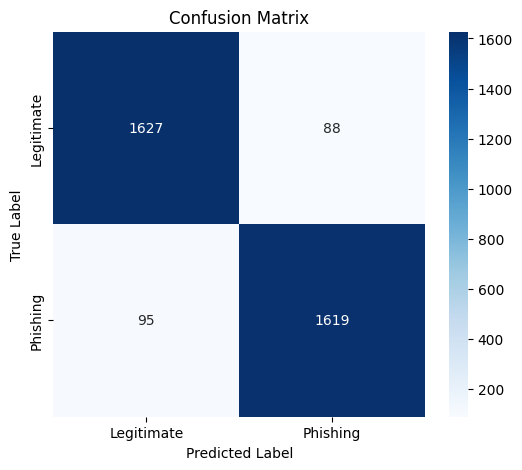

In [4]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)




plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Legitimate","Phishing"],
            yticklabels=["Legitimate","Phishing"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()